# SSLPA (igraph) — Results Visualisation

Visualises results from both output subfolders:
- **`full/`** — graph stats, community sizes, label distribution
- **`evaluation/`** — cross-validated metrics, confusion matrix, per-node outcomes

Run cells top-to-bottom. Large files are streamed in chunks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

BASE = Path('.')
EVAL = BASE / 'evaluation'
FULL = BASE / 'full'

sns.set_theme(style='whitegrid', font_scale=1.15)
ACCENT = '#2563EB'
RED    = '#DC2626'
print('Libraries ready.')

Libraries ready.


---
## 1  Graph & Algorithm Summary ()

In [2]:
stats = pd.read_csv(FULL / 'sslpa_tx_lcc_sslpa_stats.csv')
row   = stats.iloc[0]
display_cols = ['nodes','edges','num_igraph_communities','modularity',
                'min_comm_size','max_comm_size','mean_comm_size',
                'median_comm_size','num_frozen_seeds','method']
display(stats[display_cols].T.rename(columns={0:'Value'}))

,Value
nodes,4315652
edges,7100549
num_igraph_communities,5962
modularity,0.724413
min_comm_size,1
max_comm_size,1090580
mean_comm_size,723.859779
median_comm_size,2.0
num_frozen_seeds,8336
method,igraph_sslpa_majority_vote


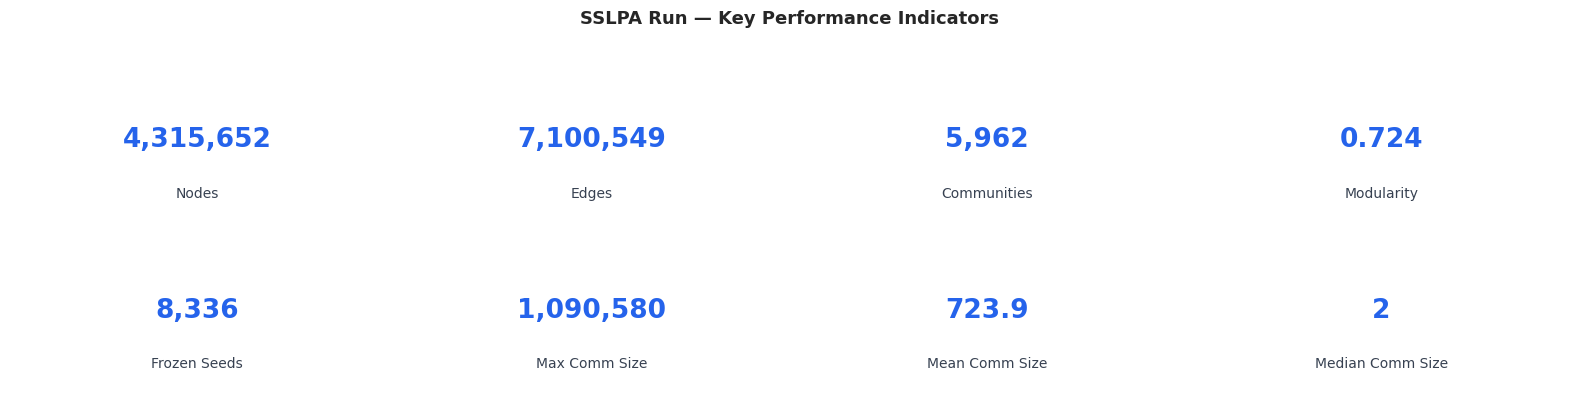

In [3]:
kpis = [
    ('Nodes',            f"{int(row['nodes']):,}"),
    ('Edges',            f"{int(row['edges']):,}"),
    ('Communities',      f"{int(row['num_igraph_communities']):,}"),
    ('Modularity',       f"{row['modularity']:.3f}"),
    ('Frozen Seeds',     f"{int(row['num_frozen_seeds']):,}"),
    ('Max Comm Size',    f"{int(row['max_comm_size']):,}"),
    ('Mean Comm Size',   f"{row['mean_comm_size']:.1f}"),
    ('Median Comm Size', f"{int(row['median_comm_size'])}"),
]
fig, axes = plt.subplots(2, 4, figsize=(16, 4))
for ax, (label, val) in zip(axes.flat, kpis):
    ax.set_facecolor('#EFF6FF')
    ax.text(0.5, 0.58, val,   ha='center', va='center',
            fontsize=19, fontweight='bold', color=ACCENT, transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha='center', va='center',
            fontsize=10, color='#374151', transform=ax.transAxes)
    ax.axis('off')
fig.suptitle('SSLPA Run — Key Performance Indicators', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE / 'vis_01_kpi_cards.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2  Community Size Distribution ()
Sizes span many orders of magnitude (min=1, max≈1 M), so we use log scales throughout.

In [4]:
print('Counting community sizes — streaming …')
counts = pd.Series(dtype='int64', name='community')
for chunk in pd.read_csv(FULL / 'sslpa_tx_lcc_lpa_communities.csv', chunksize=500_000):
    counts = counts.add(chunk['community'].value_counts(), fill_value=0)
counts = counts.astype(int).sort_values(ascending=False)
print(f'  Communities: {len(counts):,}   Total nodes: {counts.sum():,}')

Counting community sizes — streaming …
  Communities: 5,962   Total nodes: 4,315,652


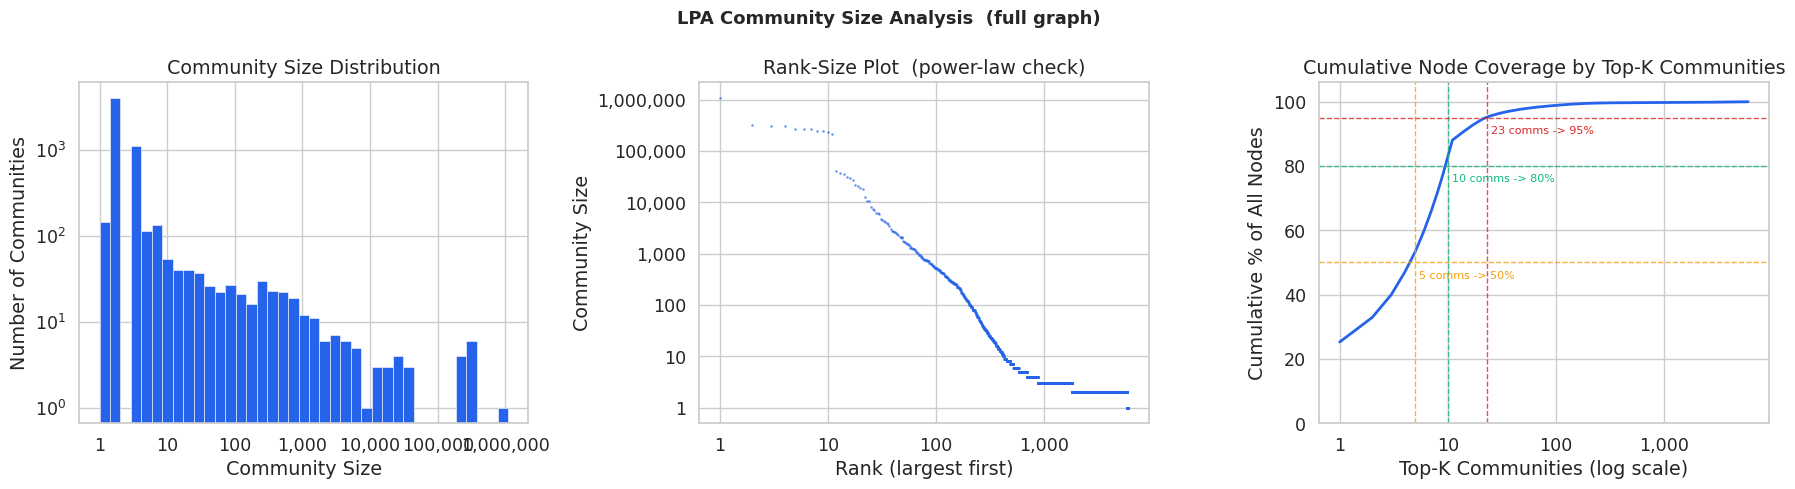

In [5]:
sizes = counts.values
ranks = np.arange(1, len(sizes) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2a  Log-scale histogram
ax = axes[0]
bins = np.logspace(0, np.log10(sizes.max() + 1), 40)
ax.hist(sizes, bins=bins, color=ACCENT, edgecolor='white', linewidth=0.4)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Community Size'); ax.set_ylabel('Number of Communities')
ax.set_title('Community Size Distribution')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 2b  Rank-size (power-law check)
ax = axes[1]
ax.loglog(ranks, sizes, '.', ms=2, alpha=0.5, color=ACCENT)
ax.set_xlabel('Rank (largest first)'); ax.set_ylabel('Community Size')
ax.set_title('Rank-Size Plot  (power-law check)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 2c  Cumulative node coverage
ax = axes[2]
cum_nodes = np.cumsum(sizes) / sizes.sum() * 100
ax.plot(ranks, cum_nodes, color=ACCENT, linewidth=2)
for pct, col in [(50, '#F59E0B'), (80, '#10B981'), (95, RED)]:
    k = int(np.searchsorted(cum_nodes, pct)) + 1
    ax.axhline(pct, ls='--', color=col, lw=1, alpha=0.8)
    ax.axvline(k,   ls='--', color=col, lw=1, alpha=0.8)
    ax.text(k * 1.08, pct - 2.5, f'{k:,} comms -> {pct}%',
            fontsize=8, color=col, va='top')
ax.set_xscale('log')
ax.set_xlabel('Top-K Communities (log scale)'); ax.set_ylabel('Cumulative % of All Nodes')
ax.set_title('Cumulative Node Coverage by Top-K Communities')
ax.set_ylim(0, 106)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('LPA Community Size Analysis  (full graph)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'vis_02_community_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3  SSLPA Label Distribution ()

In [6]:
print('Counting SSLPA labels — streaming …')
label_counts = pd.Series(dtype='int64', name='label')
for chunk in pd.read_csv(FULL / 'sslpa_tx_lcc_sslpa_labels.csv', chunksize=500_000):
    label_counts = label_counts.add(chunk['label'].value_counts(), fill_value=0)
label_counts = label_counts.astype(int).sort_values(ascending=False)
named   = label_counts[~label_counts.index.str.startswith('CLUSTER_')]
cluster = label_counts[ label_counts.index.str.startswith('CLUSTER_')]
print(f'  Named: {len(named)}   CLUSTER_X groups: {len(cluster):,}')

Counting SSLPA labels — streaming …
  Named: 212   CLUSTER_X groups: 5,750


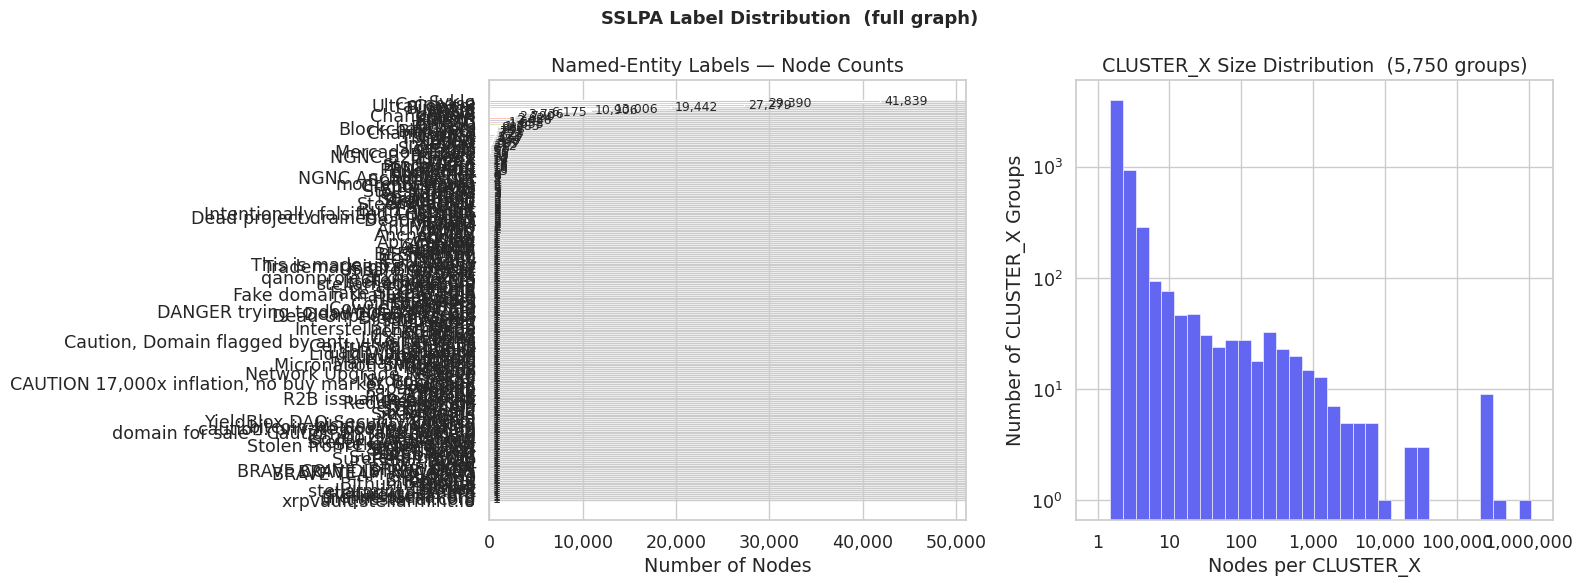

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3a  Named-entity bar
ax = axes[0]
cols_ = sns.color_palette('Set2', len(named))
bars_ = ax.barh(named.index[::-1], named.values[::-1], color=cols_[::-1])
ax.set_xlabel('Number of Nodes')
ax.set_title('Named-Entity Labels — Node Counts')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars_, named.values[::-1]):
    ax.text(val + named.max() * 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlim(0, named.max() * 1.22)

# 3b  CLUSTER_X histogram
ax = axes[1]
cv   = cluster.values
bins = np.logspace(0, np.log10(cv.max() + 1), 35)
ax.hist(cv, bins=bins, color='#6366F1', edgecolor='white', linewidth=0.4)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Nodes per CLUSTER_X'); ax.set_ylabel('Number of CLUSTER_X Groups')
ax.set_title(f'CLUSTER_X Size Distribution  ({len(cluster):,} groups)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('SSLPA Label Distribution  (full graph)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'vis_03_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
named_total   = int(named.sum())
cluster_total = int(cluster.sum())
total_nodes   = named_total + cluster_total

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
wedges, texts, autotexts = ax.pie(
    [named_total, cluster_total],
    labels=['Named Entities', 'CLUSTER_X (unlabelled)'],
    autopct='%1.1f%%', colors=['#10B981', '#CBD5E1'],
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2), pctdistance=0.75)
for t in autotexts: t.set_fontsize(12); t.set_fontweight('bold')
ax.set_title(f'Node Share: Named vs Unlabelled
(total {total_nodes:,} nodes)', fontsize=12)

ax = axes[1]
colors2 = sns.color_palette('Set2', len(named))
wedges2, texts2, autotexts2 = ax.pie(
    named.values, labels=named.index,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    colors=colors2, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.78, labeldistance=1.12)
for t in texts2:     t.set_fontsize(10)
for t in autotexts2: t.set_fontsize(9)
ax.set_title(f'Named-Entity Breakdown
({named_total:,} nodes)', fontsize=12)

fig.suptitle('SSLPA Label Composition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'vis_04_label_pies.png', dpi=150, bbox_inches='tight')
plt.show()

SyntaxError: unterminated f-string literal (detected at line 14) (1785239928.py, line 14)

---
## 4  Cross-Validation: Per-Fold Metrics ()

In [9]:
folds   = pd.read_csv(EVAL / 'sslpa_eval_per_fold.csv')
summary = pd.read_csv(EVAL / 'sslpa_eval_summary.csv')
folds['fold'] = folds['fold'].astype(str)
display(folds)

,fold,train_seeds,test_seeds,reached,missed_cluster_x,coverage,accuracy_reached,NMI_all,ARI_all,AMI_all,...,V-measure_all,Purity_all,NMI_reached,ARI_reached,AMI_reached,FMI_reached,Homogeneity_reached,Completeness_reached,V-measure_reached,Purity_reached
0,1,266,67,27,40,0.402985,0.925926,0.195492,0.045296,0.056363,...,0.195492,0.880597,0.665642,0.800627,0.635407,0.942079,0.650003,0.682053,0.665642,0.925926
1,2,266,67,24,43,0.358209,0.958333,0.221764,0.023283,0.093684,...,0.221764,0.910448,0.834762,0.855823,0.812071,0.944823,0.906229,0.773744,0.834762,0.958333
2,3,266,67,21,46,0.313433,0.952381,0.218495,0.001290,0.089400,...,0.218495,0.895522,0.771250,0.755877,0.748141,0.946229,1.000000,0.627670,0.771250,1.000000
3,4,267,66,28,38,0.424242,1.000000,0.259212,0.075103,0.137920,...,0.259212,0.939394,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,5,267,66,25,41,0.378788,0.960000,0.269609,0.054242,0.142843,...,0.269609,0.924242,0.818510,0.816946,0.802077,0.954074,1.000000,0.692777,0.818510,1.000000


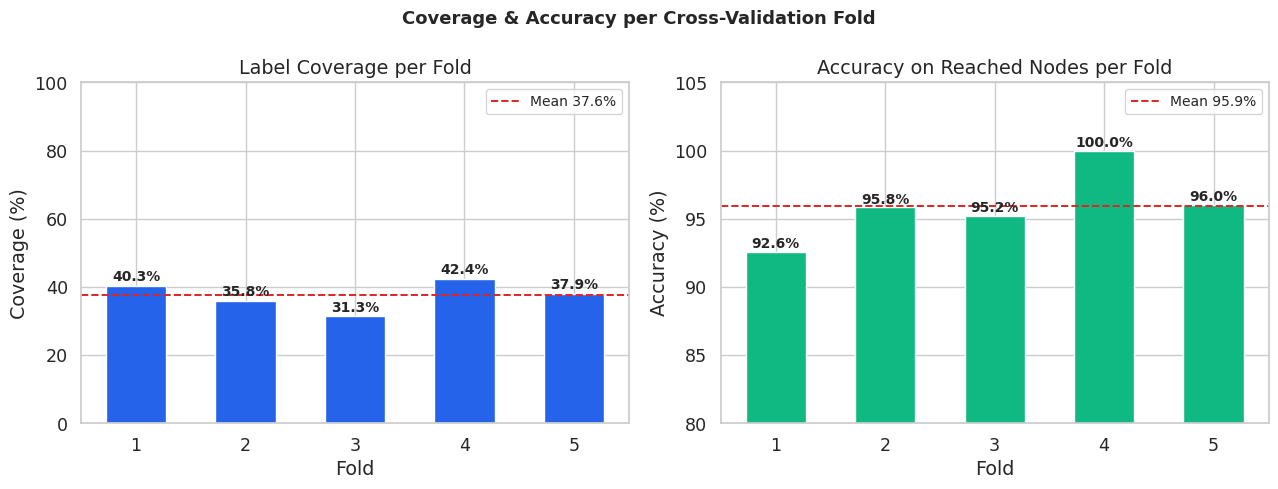

In [10]:
mean_cov = folds['coverage'].mean() * 100
mean_acc = folds['accuracy_reached'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(folds['fold'], folds['coverage']*100, color=ACCENT, width=0.55)
ax.set_ylim(0, 100); ax.set_xlabel('Fold'); ax.set_ylabel('Coverage (%)')
ax.set_title('Label Coverage per Fold')
ax.axhline(mean_cov, color=RED, ls='--', lw=1.4, label=f'Mean {mean_cov:.1f}%')
ax.legend(fontsize=10)
for bar, val in zip(bars, folds['coverage']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
            f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax = axes[1]
bars = ax.bar(folds['fold'], folds['accuracy_reached']*100, color='#10B981', width=0.55)
ax.set_ylim(80, 105); ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy on Reached Nodes per Fold')
ax.axhline(mean_acc, color=RED, ls='--', lw=1.4, label=f'Mean {mean_acc:.1f}%')
ax.legend(fontsize=10)
for bar, val in zip(bars, folds['accuracy_reached']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Coverage & Accuracy per Cross-Validation Fold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'vis_05_coverage_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

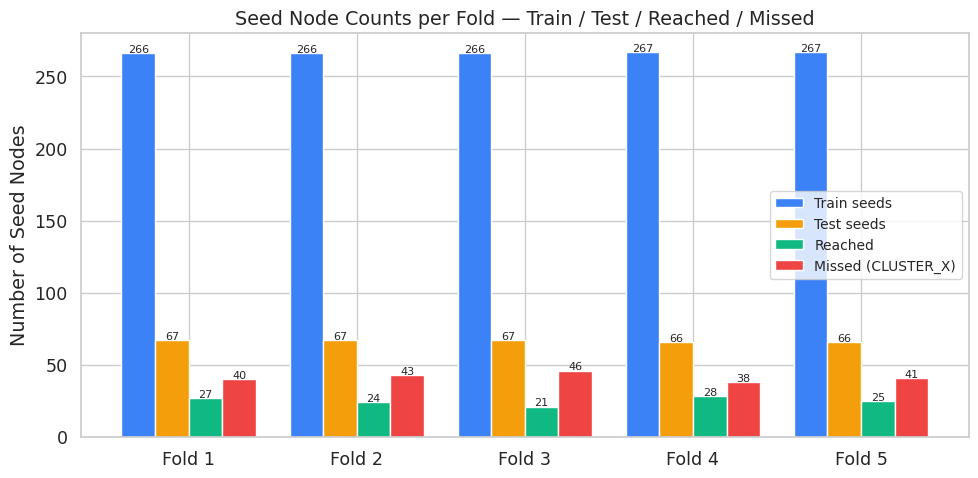

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
x  = np.arange(len(folds))
w  = 0.2
groups = [
    ('train_seeds',      'Train seeds',       '#3B82F6'),
    ('test_seeds',       'Test seeds',         '#F59E0B'),
    ('reached',          'Reached',            '#10B981'),
    ('missed_cluster_x', 'Missed (CLUSTER_X)', '#EF4444'),
]
for i, (col, label, color) in enumerate(groups):
    offset = (i - 1.5) * w
    bars = ax.bar(x + offset, folds[col], width=w, label=label, color=color)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                str(int(bar.get_height())), ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {f}' for f in folds['fold']])
ax.set_ylabel('Number of Seed Nodes')
ax.set_title('Seed Node Counts per Fold — Train / Test / Reached / Missed')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(BASE / 'vis_06_seed_counts.png', dpi=150, bbox_inches='tight')
plt.show()

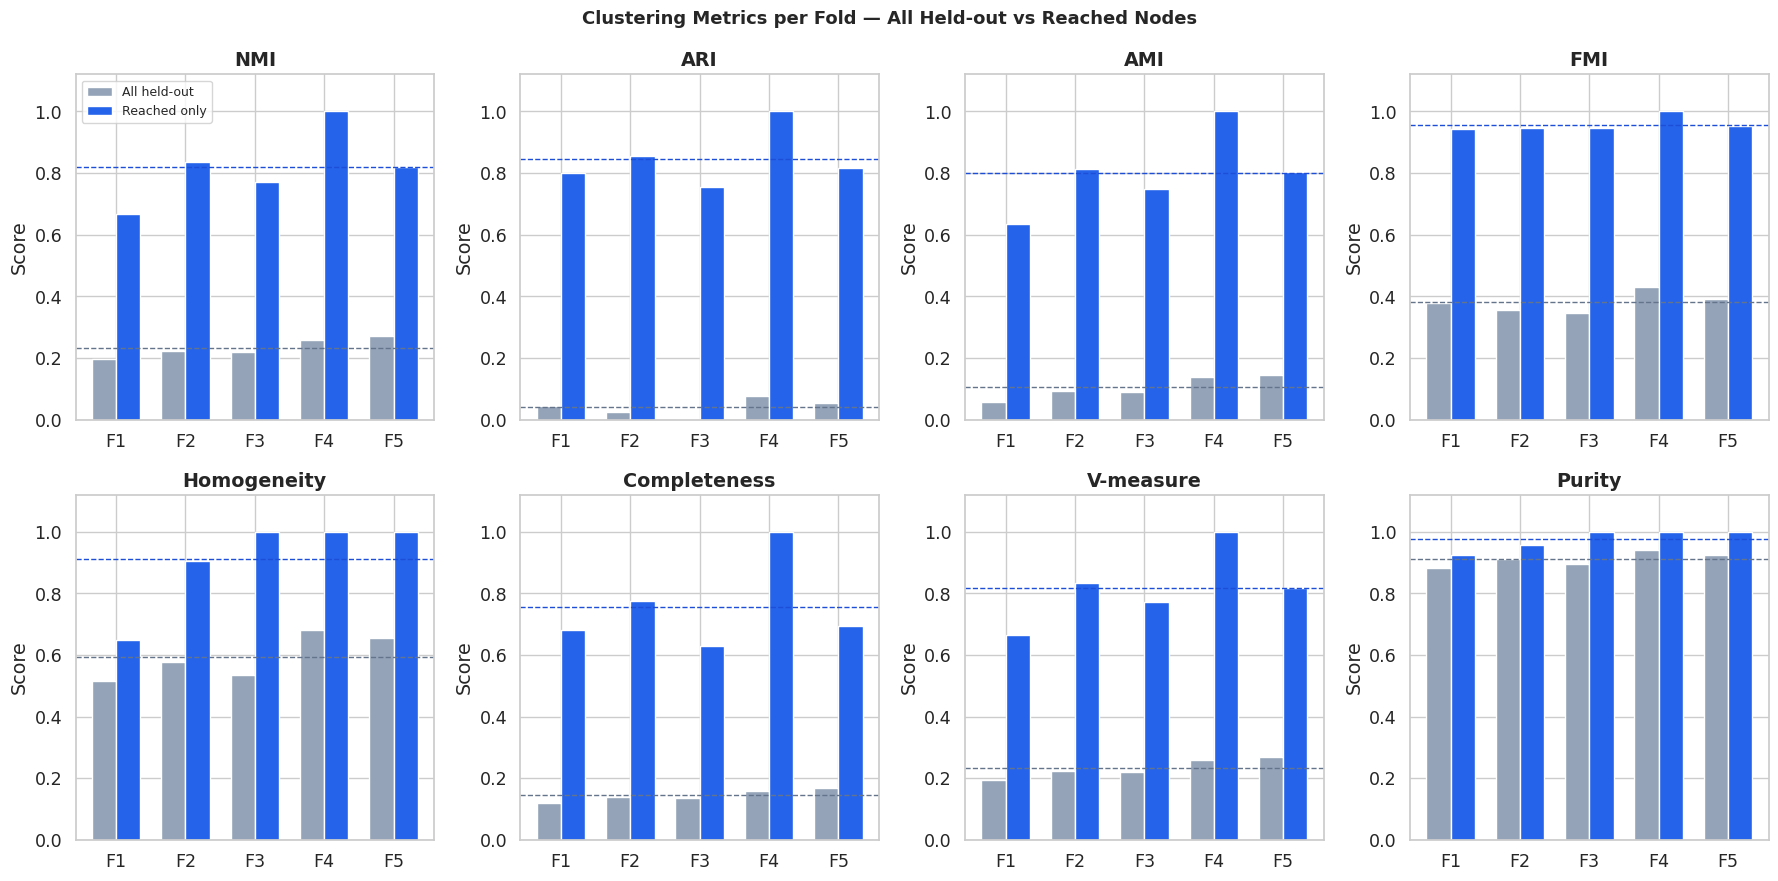

In [12]:
metrics_base = ['NMI','ARI','AMI','FMI','Homogeneity','Completeness','V-measure','Purity']
all_cols     = [f'{m}_all'     for m in metrics_base]
reach_cols   = [f'{m}_reached' for m in metrics_base]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
w_m = 0.35
for i, (metric, col_a, col_r) in enumerate(zip(metrics_base, all_cols, reach_cols)):
    ax  = axes.flat[i]
    x_m = np.arange(len(folds))
    ax.bar(x_m - w_m/2, folds[col_a], width=w_m, color='#94A3B8', label='All held-out')
    ax.bar(x_m + w_m/2, folds[col_r], width=w_m, color=ACCENT,    label='Reached only')
    ax.axhline(folds[col_a].mean(), ls='--', color='#64748B', lw=1)
    ax.axhline(folds[col_r].mean(), ls='--', color='#1D4ED8', lw=1)
    ax.set_xticks(x_m)
    ax.set_xticklabels([f'F{f}' for f in folds['fold']])
    ax.set_ylim(0, 1.12); ax.set_ylabel('Score'); ax.set_title(metric, fontweight='bold')
    if i == 0: ax.legend(fontsize=9)

fig.suptitle('Clustering Metrics per Fold — All Held-out vs Reached Nodes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'vis_07_metrics_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5  Metric Summary: All vs Reached ()

In [13]:
display(summary)

,scope,metric,mean,std
0,All held-out,NMI,0.232914,0.030703
1,All held-out,ARI,0.039843,0.028464
2,All held-out,AMI,0.104042,0.036222
3,All held-out,FMI,0.380591,0.034099
4,All held-out,Homogeneity,0.593063,0.073160
5,All held-out,Completeness,0.144969,0.019674
6,All held-out,V-measure,0.232914,0.030703
7,All held-out,Purity,0.910041,0.023136
8,Reached only,NMI,0.818033,0.121247
9,Reached only,ARI,0.845855,0.093324


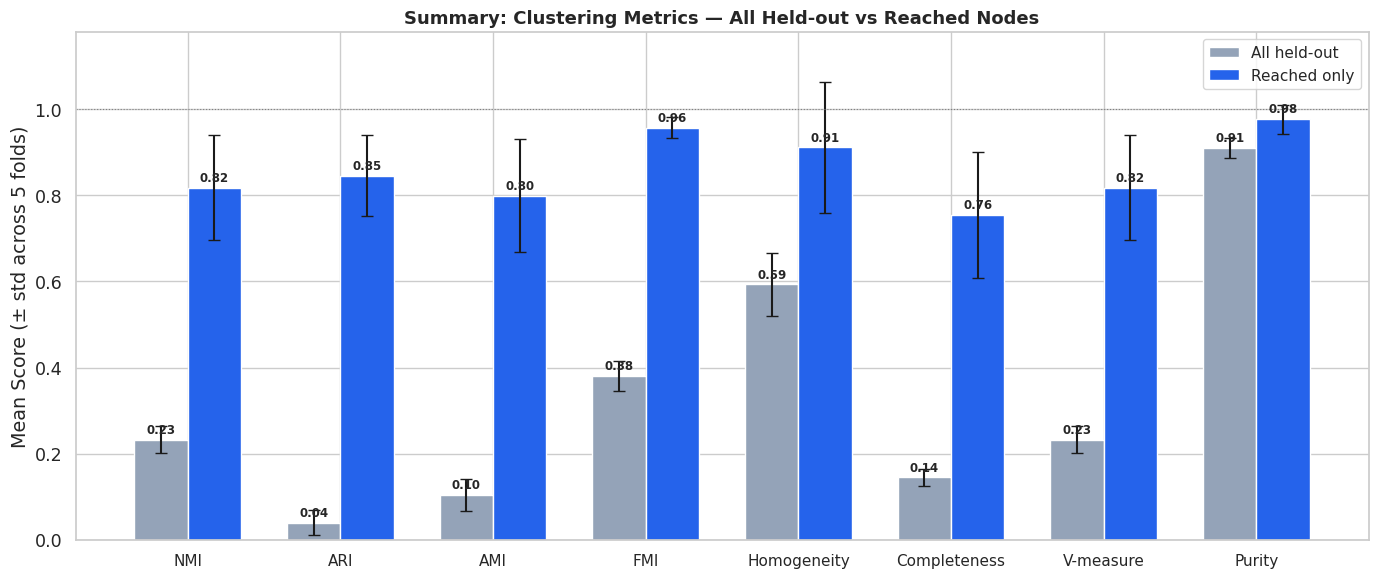

In [14]:
all_s   = summary[summary['scope'] == 'All held-out'].set_index('metric')
reach_s = summary[summary['scope'] == 'Reached only'].set_index('metric')
metric_order = ['NMI','ARI','AMI','FMI','Homogeneity','Completeness','V-measure','Purity']
x_ = np.arange(len(metric_order))
w_ = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x_ - w_/2, all_s.loc[metric_order,'mean'],   width=w_, color='#94A3B8',
            label='All held-out', yerr=all_s.loc[metric_order,'std'],   capsize=4)
b2 = ax.bar(x_ + w_/2, reach_s.loc[metric_order,'mean'], width=w_, color=ACCENT,
            label='Reached only', yerr=reach_s.loc[metric_order,'std'], capsize=4)
for bars_, scope_ in [(b1, all_s), (b2, reach_s)]:
    for bar_, m_ in zip(bars_, metric_order):
        v_ = scope_.loc[m_,'mean']
        ax.text(bar_.get_x()+bar_.get_width()/2, bar_.get_height()+0.015,
                f'{v_:.2f}', ha='center', fontsize=8.5, fontweight='bold')
ax.set_xticks(x_); ax.set_xticklabels(metric_order, fontsize=11)
ax.set_ylim(0, 1.18); ax.set_ylabel('Mean Score (± std across 5 folds)')
ax.set_title('Summary: Clustering Metrics — All Held-out vs Reached Nodes',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(1.0, ls=':', color='grey', lw=0.8)
plt.tight_layout()
plt.savefig(BASE / 'vis_08_metric_summary.png', dpi=150, bbox_inches='tight')
plt.show()

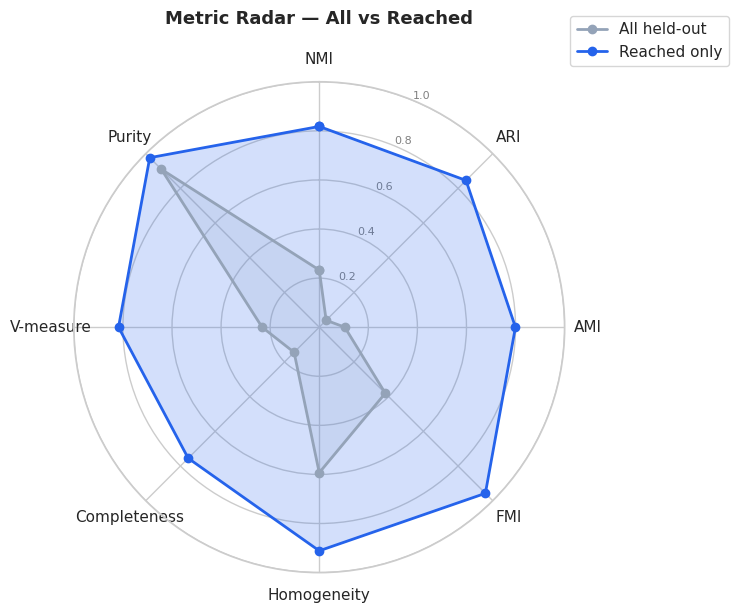

In [15]:
N      = len(metric_order)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
vals_all   = all_s.loc[metric_order,'mean'].tolist();   vals_all   += vals_all[:1]
vals_reach = reach_s.loc[metric_order,'mean'].tolist(); vals_reach += vals_reach[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
ax.plot(angles, vals_all,   'o-', lw=2, color='#94A3B8', label='All held-out')
ax.fill(angles, vals_all,   alpha=0.15, color='#94A3B8')
ax.plot(angles, vals_reach, 'o-', lw=2, color=ACCENT, label='Reached only')
ax.fill(angles, vals_reach, alpha=0.20, color=ACCENT)
ax.set_thetagrids(np.degrees(angles[:-1]), metric_order, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8, color='grey')
ax.set_title('Metric Radar — All vs Reached', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
plt.tight_layout()
plt.savefig(BASE / 'vis_09_radar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6  Confusion Matrix — Named Entities ()

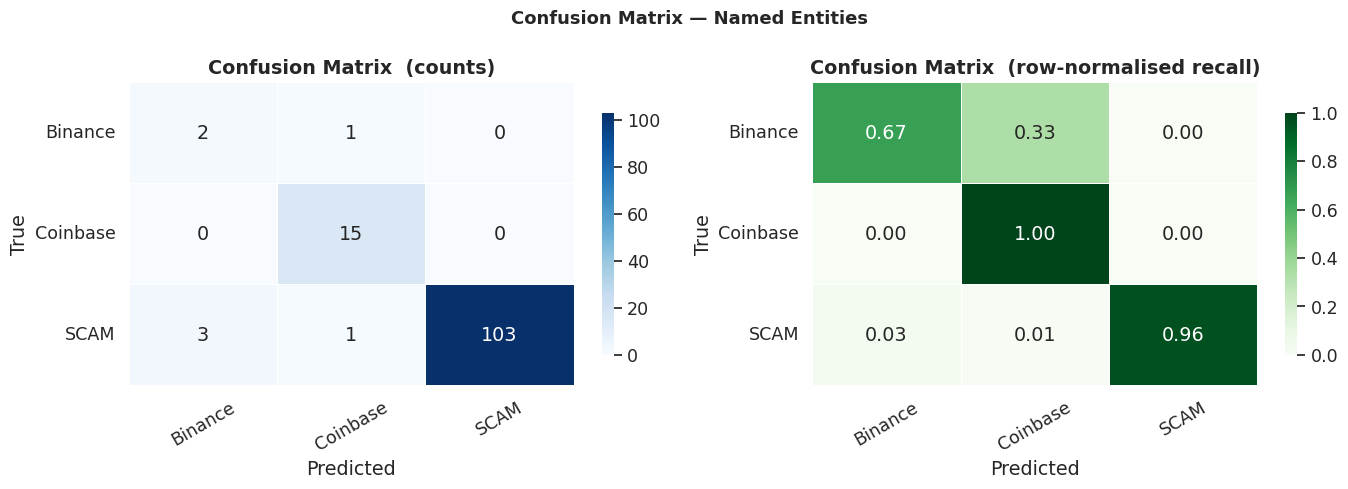

In [16]:
conf      = pd.read_csv(EVAL / 'sslpa_eval_confusion_top15.csv', index_col='true_label')
conf_heat = conf.drop(index='All', errors='ignore').drop(columns='All', errors='ignore').astype(int)
conf_norm = conf_heat.div(conf_heat.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.heatmap(conf_heat, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Confusion Matrix  (counts)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=30); ax.tick_params(axis='y', rotation=0)

ax = axes[1]
sns.heatmap(conf_norm, annot=True, fmt='.2f', cmap='Greens',
            linewidths=0.5, linecolor='white', vmin=0, vmax=1,
            ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Confusion Matrix  (row-normalised recall)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=30); ax.tick_params(axis='y', rotation=0)

fig.suptitle('Confusion Matrix — Named Entities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'vis_10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7  Per-Node Detail Analysis ()

In [17]:
nodes = pd.read_csv(EVAL / 'sslpa_eval_node_details.csv')
nodes['fold'] = nodes['fold'].astype(str)
print(f'Evaluation nodes: {len(nodes):,}')
display(nodes.head())

Evaluation nodes: 333


,fold,node,true_label,pred_label,correct,reached
0,1,270,SCAM,CLUSTER_0,False,False
1,1,11063,Coinbase,Coinbase,True,True
2,1,16104,Coinbase,Coinbase,True,True
3,1,18233,Coinbase,Coinbase,True,True
4,1,22116,SCAM,CLUSTER_0,False,False


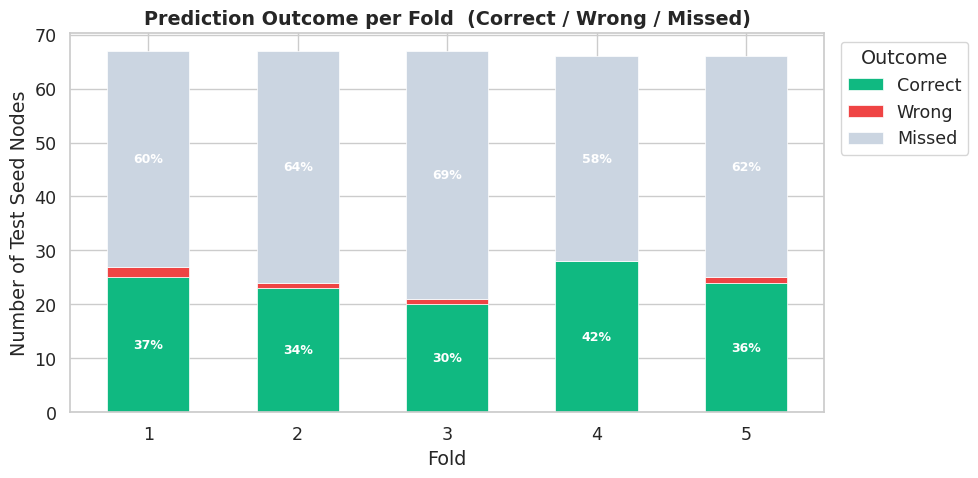

In [18]:
def classify(r):
    if not r['reached']: return 'Missed'
    return 'Correct' if r['correct'] else 'Wrong'

nodes['outcome'] = nodes.apply(classify, axis=1)
outcome_fold = (nodes.groupby(['fold','outcome'])
                     .size().unstack(fill_value=0)
                     .reindex(columns=['Correct','Wrong','Missed'], fill_value=0))

fig, ax = plt.subplots(figsize=(10, 5))
outcome_fold.plot(kind='bar', stacked=True, ax=ax,
                  color=['#10B981','#EF4444','#CBD5E1'],
                  edgecolor='white', linewidth=0.5, width=0.55)
ax.tick_params(axis='x', rotation=0)
ax.set_xlabel('Fold'); ax.set_ylabel('Number of Test Seed Nodes')
ax.set_title('Prediction Outcome per Fold  (Correct / Wrong / Missed)', fontweight='bold')
ax.legend(title='Outcome', bbox_to_anchor=(1.01,1), loc='upper left')

totals     = outcome_fold.sum(axis=1).values
cumulative = np.zeros(len(outcome_fold))
for col in ['Correct','Wrong','Missed']:
    vals = outcome_fold[col].values
    for i, (v, tot, cum) in enumerate(zip(vals, totals, cumulative)):
        if tot > 0 and v/tot > 0.05:
            ax.text(i, cum+v/2, f'{v/tot*100:.0f}%',
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    cumulative += vals

plt.tight_layout()
plt.savefig(BASE / 'vis_11_outcome_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()

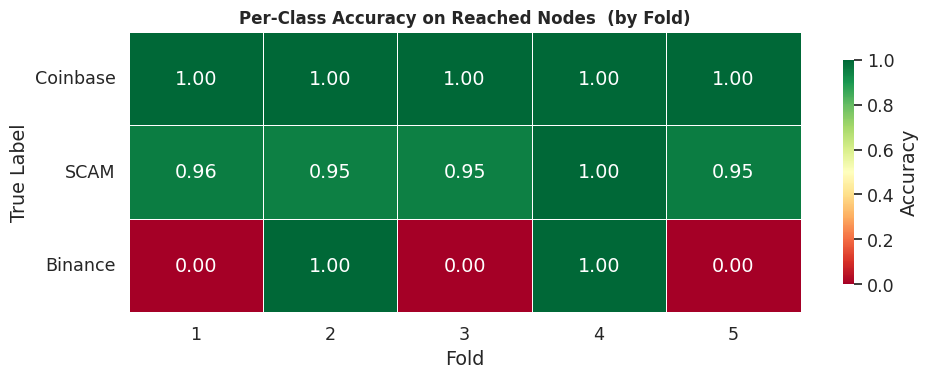

In [19]:
reached_nodes = nodes[nodes['reached']]
per_class_fold = (reached_nodes
                  .groupby(['true_label','fold'])['correct']
                  .mean().unstack('fold').fillna(0))
per_class_fold = per_class_fold.loc[
    per_class_fold.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(10, max(4, len(per_class_fold)*0.7 + 1)))
sns.heatmap(per_class_fold, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'label':'Accuracy','shrink':0.8})
ax.set_title('Per-Class Accuracy on Reached Nodes  (by Fold)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Fold'); ax.set_ylabel('True Label')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(BASE / 'vis_12_perclass_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

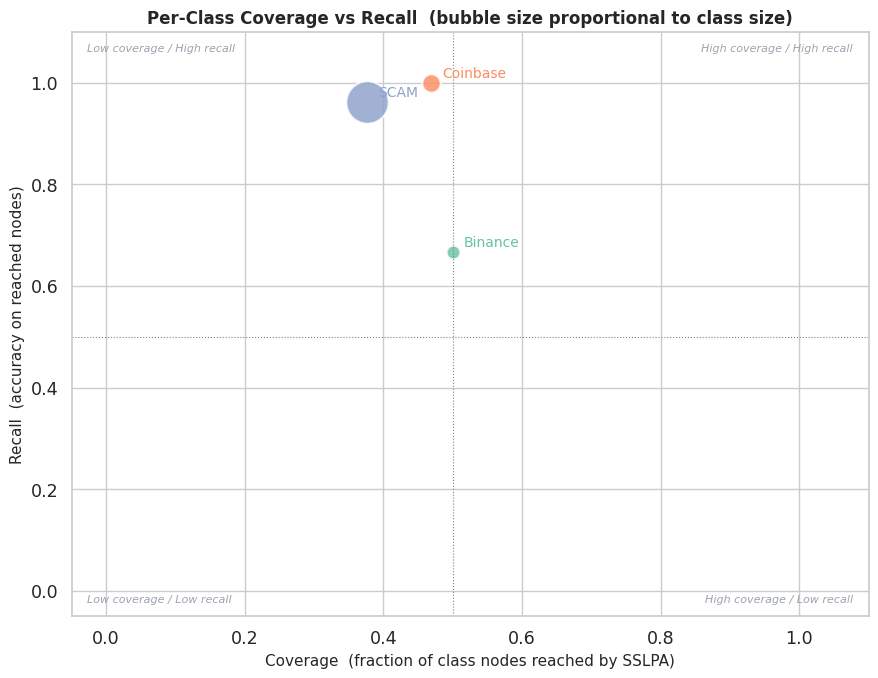

In [20]:
class_stats = (
    nodes.groupby('true_label')
    .agg(total=('node','count'), reached_n=('reached','sum'), correct_n=('correct','sum'))
)
class_stats['coverage'] = class_stats['reached_n'] / class_stats['total']
class_stats['recall']   = class_stats['correct_n']  / class_stats['reached_n']

fig, ax = plt.subplots(figsize=(9, 7))
colors3 = sns.color_palette('Set2', len(class_stats))
for (label, r), color in zip(class_stats.iterrows(), colors3):
    ax.scatter(r['coverage'], r['recall'],
               s=r['total']*3+80, color=color, alpha=0.82,
               edgecolor='white', linewidth=1.5)
    ax.annotate(label, (r['coverage'], r['recall']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=10, color=color)
ax.axhline(0.5, ls=':', color='grey', lw=0.8)
ax.axvline(0.5, ls=':', color='grey', lw=0.8)
ax.set_xlim(-0.05, 1.1); ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('Coverage  (fraction of class nodes reached by SSLPA)', fontsize=11)
ax.set_ylabel('Recall  (accuracy on reached nodes)', fontsize=11)
ax.set_title('Per-Class Coverage vs Recall  (bubble size proportional to class size)',
             fontsize=12, fontweight='bold')
for txt, xy, ha, va in [
    ('Low coverage / High recall',  (0.02, 0.98), 'left',  'top'),
    ('High coverage / High recall', (0.98, 0.98), 'right', 'top'),
    ('Low coverage / Low recall',   (0.02, 0.02), 'left',  'bottom'),
    ('High coverage / Low recall',  (0.98, 0.02), 'right', 'bottom'),
]:
    ax.text(*xy, txt, transform=ax.transAxes, fontsize=8,
            color='#9CA3AF', ha=ha, va=va, style='italic')
plt.tight_layout()
plt.savefig(BASE / 'vis_13_coverage_recall_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8  Combined Dashboard

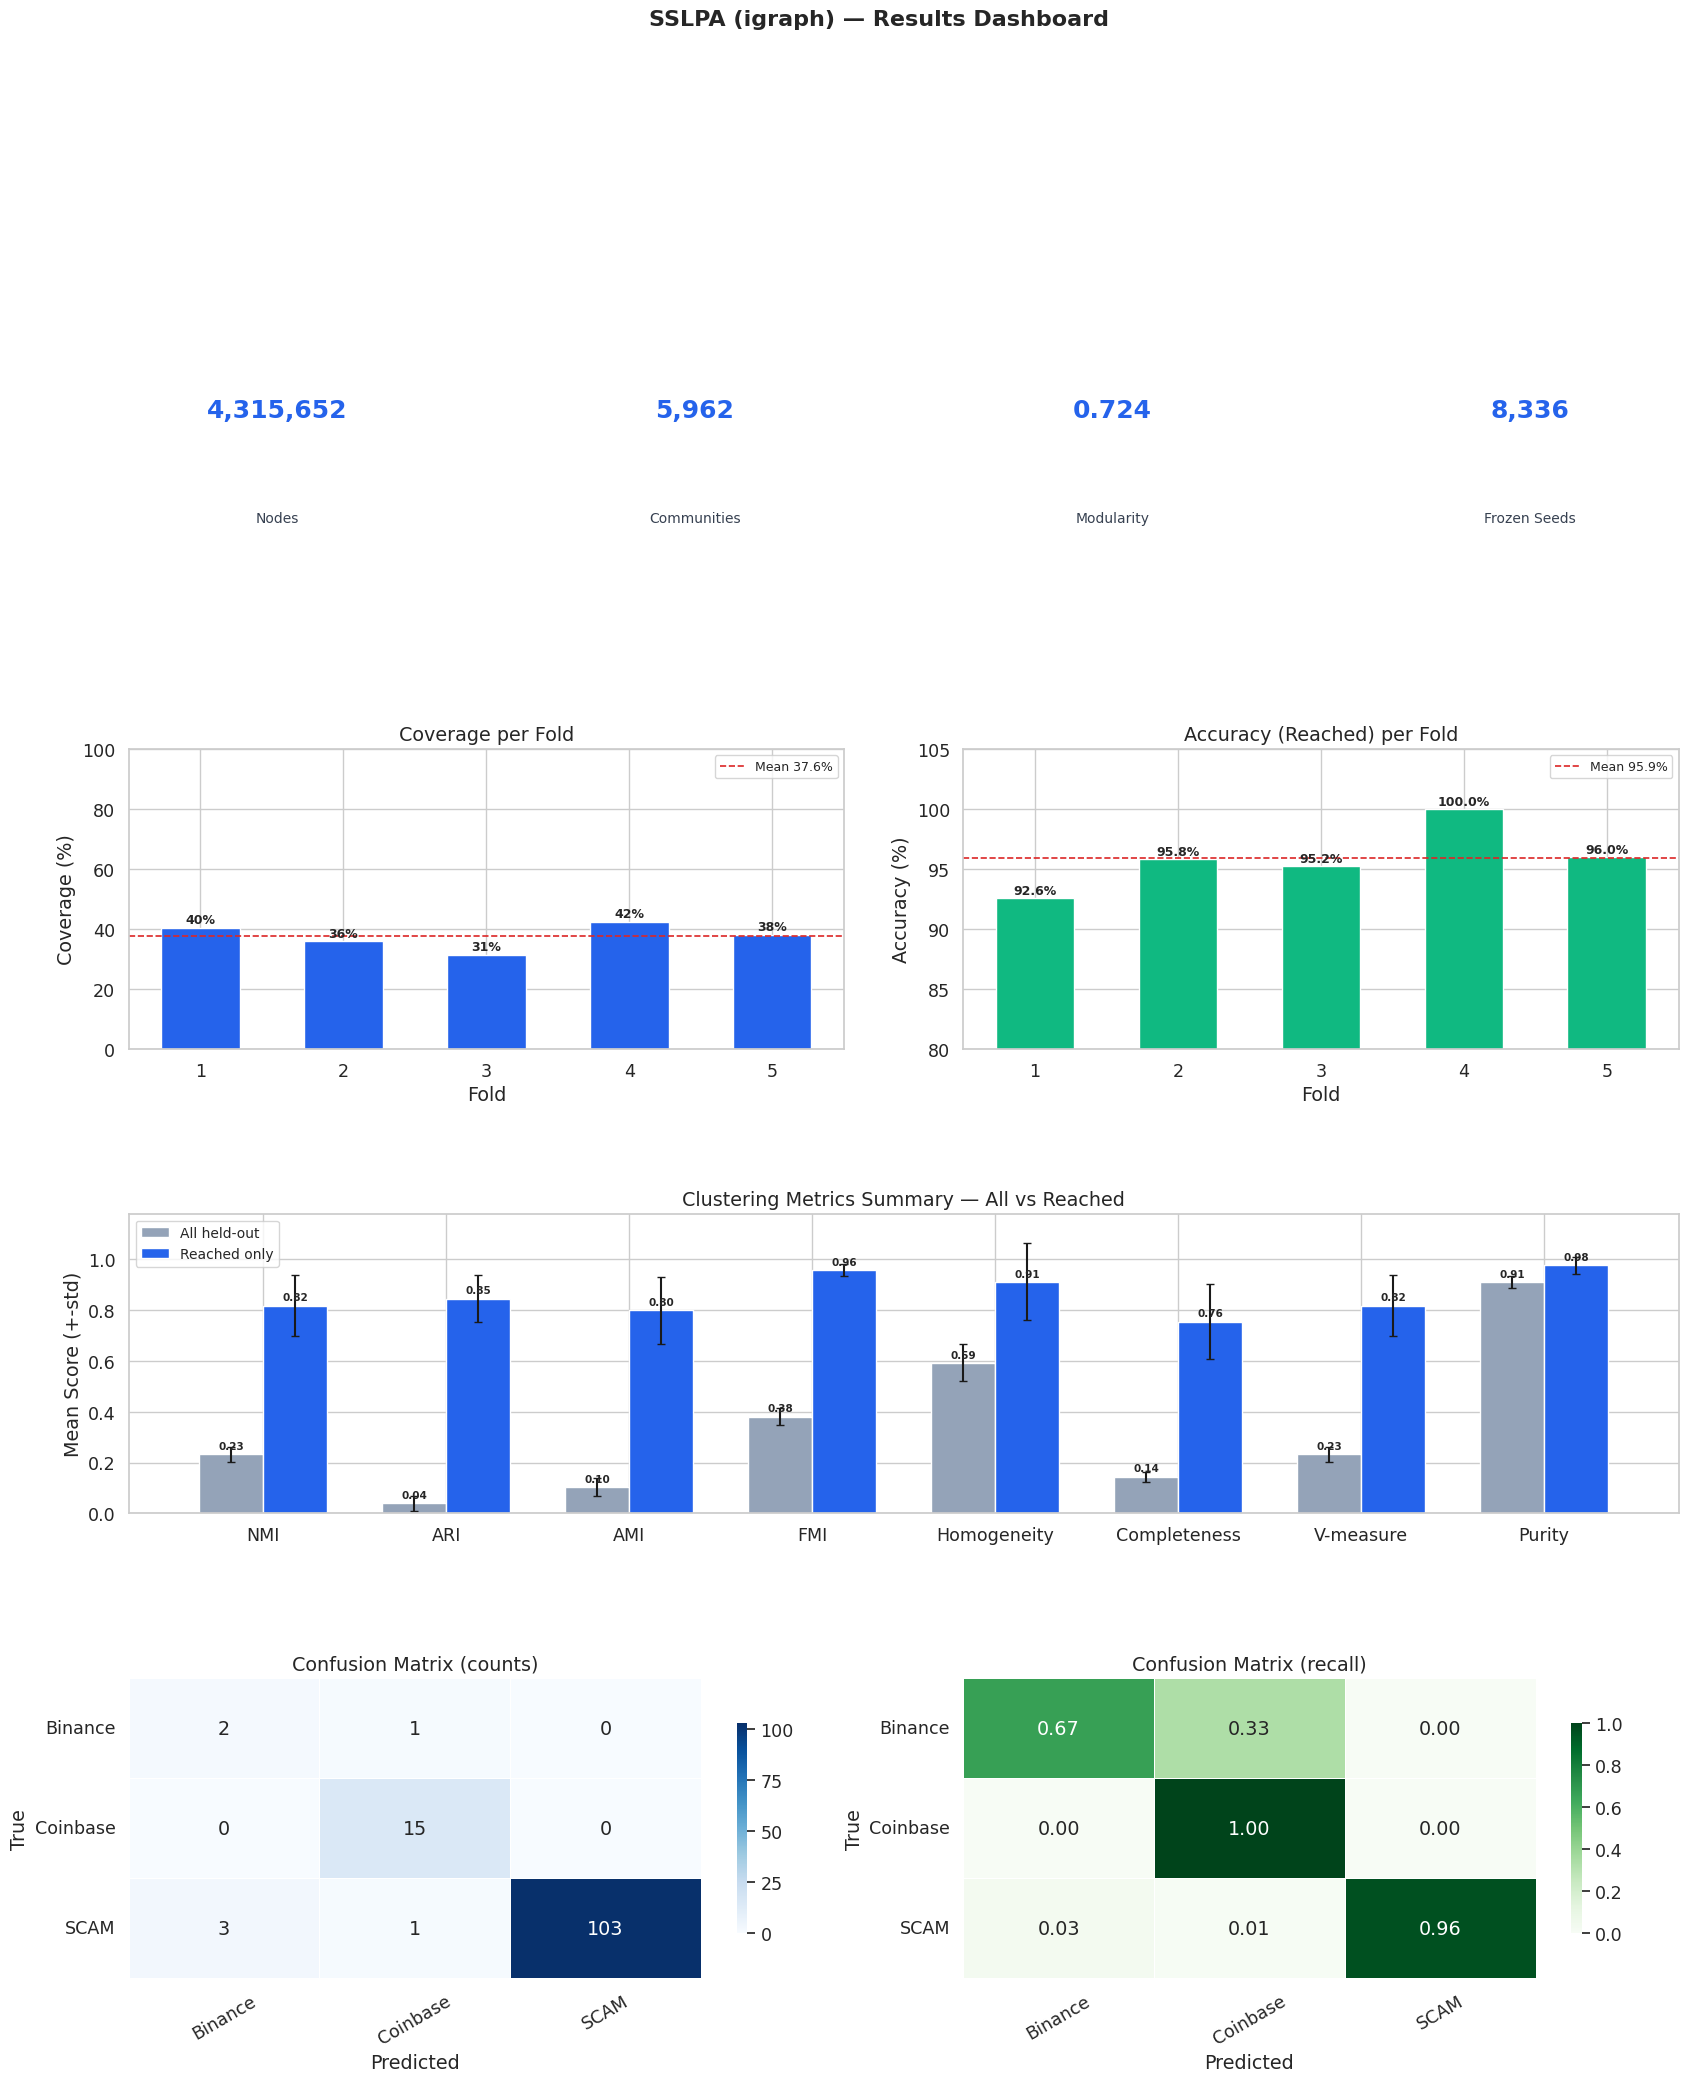

Dashboard saved -> vis_00_dashboard.png


In [21]:
fig = plt.figure(figsize=(20, 22))
gs  = fig.add_gridspec(4, 4, hspace=0.55, wspace=0.4)

# Row 0: KPI cards
kpi_subset = [
    ('Nodes',        f"{int(row['nodes']):,}"),
    ('Communities',  f"{int(row['num_igraph_communities']):,}"),
    ('Modularity',   f"{row['modularity']:.3f}"),
    ('Frozen Seeds', f"{int(row['num_frozen_seeds']):,}"),
]
for col, (label, val) in enumerate(kpi_subset):
    axi = fig.add_subplot(gs[0, col])
    axi.set_facecolor('#EFF6FF')
    axi.text(0.5, 0.58, val,   ha='center', va='center',
             fontsize=18, fontweight='bold', color=ACCENT, transform=axi.transAxes)
    axi.text(0.5, 0.22, label, ha='center', va='center',
             fontsize=10, color='#374151', transform=axi.transAxes)
    axi.axis('off')

# Row 1: coverage + accuracy
ax1 = fig.add_subplot(gs[1, :2])
bars = ax1.bar(folds['fold'], folds['coverage']*100, color=ACCENT, width=0.55)
ax1.set_ylim(0, 100); ax1.set_xlabel('Fold'); ax1.set_ylabel('Coverage (%)')
ax1.set_title('Coverage per Fold')
ax1.axhline(mean_cov, color=RED, ls='--', lw=1.2, label=f'Mean {mean_cov:.1f}%')
ax1.legend(fontsize=9)
for bar, val in zip(bars, folds['coverage']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
             f'{val*100:.0f}%', ha='center', fontsize=9, fontweight='bold')

ax2 = fig.add_subplot(gs[1, 2:])
bars2 = ax2.bar(folds['fold'], folds['accuracy_reached']*100, color='#10B981', width=0.55)
ax2.set_ylim(80, 105); ax2.set_xlabel('Fold'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy (Reached) per Fold')
ax2.axhline(mean_acc, color=RED, ls='--', lw=1.2, label=f'Mean {mean_acc:.1f}%')
ax2.legend(fontsize=9)
for bar, val in zip(bars2, folds['accuracy_reached']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Row 2: metric summary
ax3 = fig.add_subplot(gs[2, :])
b1_ = ax3.bar(x_ - w_/2, all_s.loc[metric_order,'mean'],   width=w_, color='#94A3B8',
              label='All held-out', yerr=all_s.loc[metric_order,'std'],   capsize=3)
b2_ = ax3.bar(x_ + w_/2, reach_s.loc[metric_order,'mean'], width=w_, color=ACCENT,
              label='Reached only', yerr=reach_s.loc[metric_order,'std'], capsize=3)
ax3.set_xticks(x_); ax3.set_xticklabels(metric_order)
ax3.set_ylim(0, 1.18); ax3.set_ylabel('Mean Score (+-std)')
ax3.set_title('Clustering Metrics Summary — All vs Reached'); ax3.legend(fontsize=10)
for bars_, scope_ in [(b1_, all_s), (b2_, reach_s)]:
    for bar_, m_ in zip(bars_, metric_order):
        ax3.text(bar_.get_x()+bar_.get_width()/2, bar_.get_height()+0.02,
                 f'{scope_.loc[m_,"mean"]:.2f}', ha='center', fontsize=7.5, fontweight='bold')

# Row 3: confusion matrices
ax4 = fig.add_subplot(gs[3, :2])
sns.heatmap(conf_heat, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax4, cbar_kws={'shrink':0.7})
ax4.set_title('Confusion Matrix (counts)')
ax4.set_xlabel('Predicted'); ax4.set_ylabel('True')
ax4.tick_params(axis='x', rotation=30); ax4.tick_params(axis='y', rotation=0)

ax5 = fig.add_subplot(gs[3, 2:])
sns.heatmap(conf_norm, annot=True, fmt='.2f', cmap='Greens',
            linewidths=0.5, linecolor='white', vmin=0, vmax=1,
            ax=ax5, cbar_kws={'shrink':0.7})
ax5.set_title('Confusion Matrix (recall)')
ax5.set_xlabel('Predicted'); ax5.set_ylabel('True')
ax5.tick_params(axis='x', rotation=30); ax5.tick_params(axis='y', rotation=0)

fig.suptitle('SSLPA (igraph) — Results Dashboard', fontsize=16, fontweight='bold', y=1.005)
plt.savefig(BASE / 'vis_00_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved -> vis_00_dashboard.png')

---
## Saved Figures

| File | Content |
|------|---------|
| `vis_00_dashboard.png` | Full combined dashboard |
| `vis_01_kpi_cards.png` | KPI summary cards |
| `vis_02_community_sizes.png` | Community size distribution (histogram, rank-size, coverage) |
| `vis_03_label_distribution.png` | Named-entity bar + CLUSTER_X size histogram |
| `vis_04_label_pies.png` | Pie: named vs unlabelled + entity breakdown |
| `vis_05_coverage_accuracy.png` | Coverage & accuracy per fold |
| `vis_06_seed_counts.png` | Seed node counts per fold |
| `vis_07_metrics_per_fold.png` | All 8 clustering metrics per fold (both scopes) |
| `vis_08_metric_summary.png` | Mean ± std metric summary bar |
| `vis_09_radar.png` | Radar chart (all vs reached) |
| `vis_10_confusion_matrix.png` | Confusion matrix (counts + row-normalised recall) |
| `vis_11_outcome_per_fold.png` | Correct / Wrong / Missed stacked bar |
| `vis_12_perclass_accuracy.png` | Per-class accuracy heatmap (fold × class) |
| `vis_13_coverage_recall_bubble.png` | Per-class coverage vs recall bubble chart |